In [1]:
!pip -q install pyarrow openpyxl

import pandas as pd
import matplotlib.pyplot as plt

FIRST_PATH = "/content/pirmas.parquet"
SECOND_PATH = "/content/antras.parquet"

def parse_dates_two_pass(s):
    dt = pd.to_datetime(s, errors="coerce")
    mask = dt.isna()
    if mask.any():
        dt2 = pd.to_datetime(s[mask], errors="coerce", format="%Y-%m-%d %H:%M:%S")
        dt.loc[mask] = dt2
    return dt

df1 = pd.read_parquet(FIRST_PATH)
df2 = pd.read_parquet(SECOND_PATH)

for df in (df1, df2):
    df["Order_Date_dt"] = parse_dates_two_pass(df["Order_Date"])
    df["Ship_Date_dt"] = parse_dates_two_pass(df["Ship_Date"])
    df["Ship_Duration_Days"] = (df["Ship_Date_dt"] - df["Order_Date_dt"]).dt.days

print("Original shapes:")
print("df1:", df1.shape)
print("df2:", df2.shape)
print(len(df1), len(df2))
print(len(df1) == len(df2))

Original shapes:
df1: (513628, 26)
df2: (513628, 26)
513628 513628
True


In [2]:
summary = pd.DataFrame({
    "Pirmas": [
        df1["Gross_Sales"].sum(),
        df1["Net_Sales"].sum(),
        df1["Profit"].sum(),
        df1["Profit"].mean()
    ],
    "Antras": [
        df2["Gross_Sales"].sum(),
        df2["Net_Sales"].sum(),
        df2["Profit"].sum(),
        df2["Profit"].mean()
    ]
}, index=["Gross_Sales_sum", "Net_Sales_sum", "Profit_sum", "Profit_mean"])

print(summary.round(1))

                     Pirmas      Antras
Gross_Sales_sum  93335521.3  93335521.3
Net_Sales_sum    64949098.6  88404293.1
Profit_sum        6148666.3  24027388.4
Profit_mean            12.0        46.8


In [3]:
segment_summary_1 = (
    df1.groupby("Segment")
    .agg(
        order_count=("Order_ID", "count"),
        net_sales=("Net_Sales", "sum"),
        avg_profit=("Profit", "mean")
    )
    .loc[["Consumer", "Corporate", "Home Office"]]
)

segment_summary_2 = (
    df2.groupby("Segment")
    .agg(
        order_count=("Order_ID", "count"),
        net_sales=("Net_Sales", "sum"),
        avg_profit=("Profit", "mean")
    )
    .loc[["Consumer", "Corporate", "Home Office"]]
)

print("Pirmas rinkinys")
print(segment_summary_1.round(1))
print()
print("Antras rinkinys")
print(segment_summary_2.round(1))

Pirmas rinkinys
             order_count   net_sales  avg_profit
Segment                                         
Consumer          256781  32476977.4        11.9
Corporate         154089  19551328.9        12.1
Home Office       102758  12920792.2        11.9

Antras rinkinys
             order_count   net_sales  avg_profit
Segment                                         
Consumer          256781  44219563.5        46.9
Corporate         154089  26559894.4        46.7
Home Office       102758  17624835.2        46.7


In [4]:
order = ["Same Day", "First Class", "Second Class", "Standard Class"]

ship_diff = pd.DataFrame({
    "profit_diff": (
        df2.groupby("Shipping_Mode")["Profit"].mean()
        - df1.groupby("Shipping_Mode")["Profit"].mean()
    ),
    "net_sales_diff": (
        df2.groupby("Shipping_Mode")["Net_Sales"].mean()
        - df1.groupby("Shipping_Mode")["Net_Sales"].mean()
    )
}).loc[order]

print(ship_diff.round(2))

                profit_diff  net_sales_diff
Shipping_Mode                              
Same Day              35.98           46.15
First Class           34.45           45.24
Second Class          35.21           45.53
Standard Class        34.40           45.86


In [5]:
order = ["Same Day", "First Class", "Second Class", "Standard Class"]

dur_cmp = pd.DataFrame({
    "Pirmas": df1.groupby("Shipping_Mode")["Ship_Duration_Days"].mean(),
    "Antras": df2.groupby("Shipping_Mode")["Ship_Duration_Days"].mean()
}).loc[order]

dur_cmp["Abs_diff"] = (dur_cmp["Antras"] - dur_cmp["Pirmas"]).abs()

print(dur_cmp.round(2))

bad_mode = dur_cmp["Abs_diff"].idxmax()
bad_diff = round(dur_cmp.loc[bad_mode, "Abs_diff"], 2)

max_duration_same_mode = int(max(
    df1.loc[df1["Shipping_Mode"] == bad_mode, "Ship_Duration_Days"].max(),
    df2.loc[df2["Shipping_Mode"] == bad_mode, "Ship_Duration_Days"].max()
))

print()
print("Neatitikimas:", bad_mode)
print("Skirtumas:", bad_diff)
print("Didžiausia trukmė:", max_duration_same_mode)

                Pirmas  Antras  Abs_diff
Shipping_Mode                           
Same Day          3.76    1.26      2.49
First Class       1.80    1.80      0.00
Second Class      2.80    2.80      0.00
Standard Class    3.80    3.80      0.00

Neatitikimas: Same Day
Skirtumas: 2.49
Didžiausia trukmė: 10


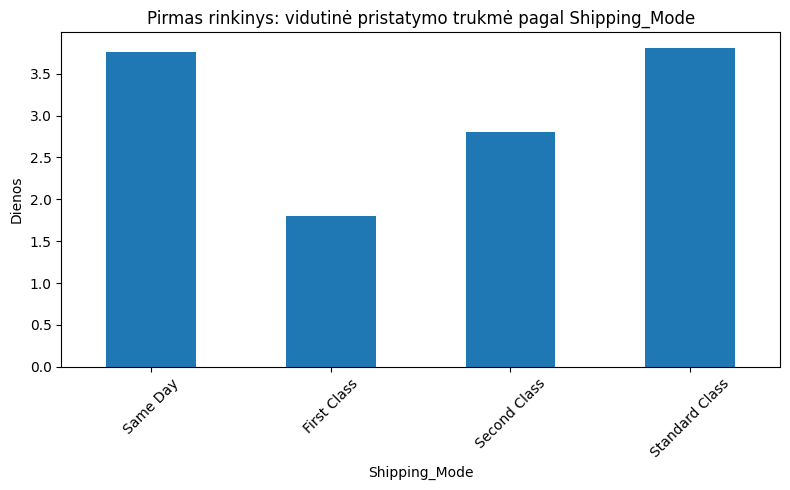

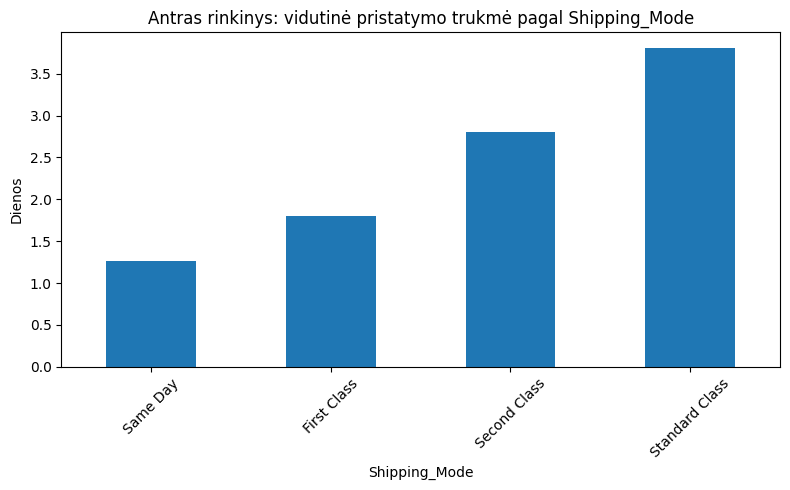

Pirmas:
Shipping_Mode
Same Day          3.76
First Class       1.80
Second Class      2.80
Standard Class    3.80
Name: Ship_Duration_Days, dtype: float64

Antras:
Shipping_Mode
Same Day          1.26
First Class       1.80
Second Class      2.80
Standard Class    3.80
Name: Ship_Duration_Days, dtype: float64


In [6]:
order = ["Same Day", "First Class", "Second Class", "Standard Class"]

avg_ship_1 = (
    df1.groupby("Shipping_Mode")["Ship_Duration_Days"]
    .mean()
    .loc[order]
)

avg_ship_2 = (
    df2.groupby("Shipping_Mode")["Ship_Duration_Days"]
    .mean()
    .loc[order]
)

plt.figure(figsize=(8,5))
avg_ship_1.plot(kind="bar")
plt.title("Pirmas rinkinys: vidutinė pristatymo trukmė pagal Shipping_Mode")
plt.ylabel("Dienos")
plt.xlabel("Shipping_Mode")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
avg_ship_2.plot(kind="bar")
plt.title("Antras rinkinys: vidutinė pristatymo trukmė pagal Shipping_Mode")
plt.ylabel("Dienos")
plt.xlabel("Shipping_Mode")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Pirmas:")
print(avg_ship_1.round(2))
print()
print("Antras:")
print(avg_ship_2.round(2))

In [7]:
net_stats = pd.DataFrame({
    "Pirmas": df1["Net_Sales"].agg(["min", "median", "mean", "max"]),
    "Antras": df2["Net_Sales"].agg(["min", "median", "mean", "max"])
})

print(net_stats.round(1))

negative_dataset = "Pirmas" if df1["Net_Sales"].min() < 0 else "Antras"
negative_min = round(min(df1["Net_Sales"].min(), df2["Net_Sales"].min()), 1)

if negative_dataset == "Pirmas":
    mean_lt_median = df1["Net_Sales"].mean() < df1["Net_Sales"].median()
else:
    mean_lt_median = df2["Net_Sales"].mean() < df2["Net_Sales"].median()

print()
print("Neigiamos reikšmės rinkinyje:", negative_dataset)
print("Minimali reikšmė:", negative_min)
print("Vidurkis < mediana:", mean_lt_median)

        Pirmas  Antras
min    -2207.6     3.0
median   109.9   136.2
mean     126.5   172.1
max     1938.3  2651.6

Neigiamos reikšmės rinkinyje: Pirmas
Minimali reikšmė: -2207.6
Vidurkis < mediana: False
